### Попробуем обучить PINN, который будет искать решения w по заданным параметрам и kx, ky

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [42]:
class BrilloinZone:
    def __init__(self, a, b, N_seg=20):
        self.a = a
        self.b = b
        self.N_seg = N_seg

    def get_path(self):
        kx1 = np.linspace(0.0, np.pi / self.a, self.N_seg, endpoint=False)
        ky1 = np.zeros(self.N_seg)

        kx2 = np.full(self.N_seg, np.pi / self.a)
        ky2 = np.linspace(0.0, np.pi / self.b, self.N_seg, endpoint=False)
        
        kx3 = np.linspace(np.pi / self.a, 0.0, self.N_seg, endpoint=True)
        ky3 = np.linspace(np.pi / self.b, 0.0, self.N_seg, endpoint=True)

        KX = np.concatenate([kx1, kx2, kx3])
        KY = np.concatenate([ky1, ky2, ky3])
        x_path = np.arange(self.N_seg * 3) / self.N_seg
        
        return KX, KY, x_path


class MetaMaterial:
    def __init__(self, a, b, theta, m_u, ks, rho, h, D, N_T=20):
        self.a = a
        self.b = b
        self.theta = theta
        self.m_u = m_u
        self.ks = ks
        self.nu = np.sqrt(ks / m_u)
        self.rho = rho
        self.h = h
        self.D = D
        self.N_T = N_T

    def _w2k(self, w):
        return (self.rho * self.h * w**2 / self.D) ** 0.25

    def DispersionEqLhs(self, w):
        k = self._w2k(w)
        mu = self.m_u * w**2 / (self.D * (1.0 - w**2 / self.nu**2))

        return 4.0 * self.b * k**3 / mu

    def DispersionEqRhs(self, kx, ky, w):
        k = self._w2k(w)
        res = 0.0 + 0j
        
        sin_t = np.sin(self.theta)
        cot_t = 0.0 if abs(np.cos(self.theta)) < 1e-10 else 1.0 / np.tan(self.theta)

        for n in range(-self.N_T, self.N_T + 1):
            kxn = kx + 2.0 * np.pi * n / self.b
            
            lambda_n = np.sqrt((kxn / k)**2 - 1 + 0j)
            gamma_n  = np.sqrt((kxn / k)**2 + 1 + 0j)
            
            arg_gamma = gamma_n * k * self.a * sin_t
            arg_lambda = lambda_n * k * self.a * sin_t
            
            denom_left = np.cos(sin_t * (ky * self.a - 2.0 * np.pi * n * self.a * cot_t / self.b))

            num_1 = np.sinh(arg_gamma)
            den_1 = denom_left - np.cosh(arg_gamma) + 1e-9
            
            num_2 = np.sinh(arg_lambda)
            den_2 = denom_left - np.cosh(arg_lambda) + 1e-9

            res += (1.0 / (gamma_n)) * (num_1 / den_1) - (1.0 / lambda_n) * (num_2 / den_2)
            
        return np.real(res)

    def DispersionEqResidual(self, kx, ky, w):
        if w < 1e-5 or abs(w - self.nu) < 1e-1:
            return 1e5
        return self.DispersionEqLhs(w) - self.DispersionEqRhs(kx, ky, w)

    def verify(self, kx, ky, w):
        lhs = self.DispersionEqLhs(w)
        rhs = self.DispersionEqRhs(kx, ky, w)
        print(f"LHS: {lhs:.5e}, RHS: {rhs:.5e}, Разница: {lhs - rhs:.5e}")

        return lhs - rhs

    def calculate_bands(self, KX, KY, w_search_array, xtol=1e-10):
        meta_x, meta_y = [], []
        x_path = np.arange(len(KX)) / (len(KX) // 3) 
        
        for i, (kx, ky) in enumerate(zip(KX, KY)):
            if i % 10 == 0:
                print(f"  Расчет k-точки {i}/{len(KX)}")
                
            res_vals = [self.DispersionEqResidual(kx, ky, w) for w in w_search_array]
            
            for j in range(len(res_vals) - 1):
                v0, v1 = res_vals[j], res_vals[j+1]
                if np.isnan(v0) or np.isnan(v1): 
                    continue
                    
                if v0 * v1 < 0.0:
                    try:
                        w_root = brentq(lambda w_val: self.DispersionEqResidual(kx, ky, w_val),
                                        w_search_array[j], w_search_array[j+1], xtol=xtol, maxiter=400)
                    
                        if abs(self.DispersionEqResidual(kx, ky, w_root)) < 1.0:
                            meta_x.append(x_path[i])
                            meta_y.append(w_root)
                    except (ValueError, RuntimeError):
                        pass
                        
        return np.array(meta_x), np.array(meta_y)


def plot_dispersion(meta_x, meta_y, meta, bz, pinn_x=None, pinn_y=None, title=None):
    fig, ax = plt.subplots(figsize=(10, 7))
    
    meta_y_hz = meta_y / (2 * np.pi)
    
    ax.scatter(meta_x, meta_y_hz, s=2, color="blue", alpha=0.5, label="Metamaterial")

    if pinn_x is not None and pinn_y is not None:
        pinn_y_hz = np.asarray(pinn_y) / (2 * np.pi)
        ax.plot(pinn_x, pinn_y_hz, color="black", linewidth=1.5, label="PINN")

    x_ticks = [0, 1, 2, 3]
    path_names = ["$\\Gamma$", "X", "M", "$\\Gamma$"]
    for xc in x_ticks[1:-1]:
        ax.axvline(x=xc, color="gray", linestyle="--")
        
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(path_names, fontsize=14)
    ax.set_xlim(0, 3)
    
    ax.set_ylim(0, 800)
    if title is not None:
        ax.set_title(title, fontsize=16)
    ax.set_ylabel("Frequency (Hz)", fontsize=14)
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")
    fig.tight_layout()
    
    KX, KY, xpth = bz.get_path()
    def onclick(event):
        if event.xdata is None or event.ydata is None: 
            return
        kx_val = np.interp(event.xdata, xpth, KX)
        ky_val = np.interp(event.xdata, xpth, KY)
        
        w_val = event.ydata * 2 * np.pi
        
        print(f"\nКлик! x: {event.xdata:.2f} -> kx: {kx_val:.4f}, ky: {ky_val:.4f}, частота: {event.ydata:.2f} Гц")
        meta.verify(kx_val, ky_val, w_val)

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()

In [43]:
class PINN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PINN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size),
        )
                
    def forward(self, x):
        out = self.model(x)
        return out

In [44]:
def PDE_loss(model, input, input_phys=None, param_cols=None, y_mean=None, y_std=None, N_T=5, eps=1e-9):
    pred_w = model(input).squeeze(-1)

    if y_mean is not None and y_std is not None:
        pred_w = pred_w * y_std.reshape(-1)[0] + y_mean.reshape(-1)[0]

    pde_input = input if input_phys is None else input_phys
    default_cols = ["kx", "ky", "a", "b", "theta", "m_u", "ks", "rho", "h", "D"]
    col_names = default_cols if param_cols is None else list(param_cols)

    if pde_input.shape[1] < len(default_cols):
        raise ValueError("input должен иметь колонки: kx, ky, a, b, theta, m_u, ks, rho, h, D")

    missing_cols = [name for name in default_cols if name not in col_names]
    if missing_cols:
        raise ValueError(f"Не хватает колонок для PDE_loss: {missing_cols}")

    cols = {name: pde_input[:, col_names.index(name)] for name in default_cols}
    kx, ky, a, b, theta, m_u, ks, rho, h, D = [cols[name] for name in default_cols]

    nu = torch.sqrt(ks / m_u)
    w = pred_w
    k = (rho * h * w**2 / D).clamp_min(eps).pow(0.25)
    mu = m_u * w**2 / (D * (1.0 - w**2 / nu**2 + eps))
    lhs = 4.0 * b * k**3 / (mu + eps)

    sin_t = torch.sin(theta)
    cot_t = torch.where(torch.abs(torch.cos(theta)) < 1e-10, torch.zeros_like(theta), 1.0 / torch.tan(theta))

    complex_dtype = torch.complex128 if input.dtype == torch.float64 else torch.complex64
    rhs = torch.zeros_like(w, dtype=complex_dtype)
    k_c = k.to(complex_dtype)

    for n in range(-N_T, N_T + 1):
        kxn = kx + 2.0 * torch.pi * n / b
        kxn_c = kxn.to(complex_dtype)

        lambda_n = torch.sqrt((kxn_c / k_c) ** 2 - 1.0 + 0j)
        gamma_n = torch.sqrt((kxn_c / k_c) ** 2 + 1.0 + 0j)

        arg_gamma = gamma_n * k_c * a.to(complex_dtype) * sin_t.to(complex_dtype)
        arg_lambda = lambda_n * k_c * a.to(complex_dtype) * sin_t.to(complex_dtype)
        denom_left = torch.cos(sin_t * (ky * a - 2.0 * torch.pi * n * a * cot_t / b)).to(complex_dtype)

        rhs += (1.0 / (gamma_n + eps)) * (torch.sinh(arg_gamma) / (denom_left - torch.cosh(arg_gamma) + eps))
        rhs -= (1.0 / (lambda_n + eps)) * (torch.sinh(arg_lambda) / (denom_left - torch.cosh(arg_lambda) + eps))

    residual = lhs - rhs.real
    return torch.mean(residual ** 2)

def DATA_loss(model, input, target):
    pred = model(input)
    if target.ndim == 1 and pred.ndim == 2 and pred.shape[1] == 1:
        target = target.unsqueeze(-1)
    return torch.mean((pred - target) ** 2)

def weighted_losses(model, x_train, y_train, PDE_weight=0.1, DATA_weight=1.0, x_pde=None, y_mean=None, y_std=None, param_cols=None):
    pde_loss = PDE_loss(
        model,
        x_train,
        input_phys=x_pde,
        param_cols=param_cols,
        y_mean=y_mean,
        y_std=y_std,
    )
    data_loss = DATA_loss(model, x_train, y_train)
    total_loss = pde_loss * PDE_weight + data_loss * DATA_weight
    return total_loss, pde_loss, data_loss

def train_pinn(model, x_train, y_train, epochs=1000, lr=1e-3, print_every=100, PDE_weight=0.1, DATA_weight=1.0, weight_decay=0.0, max_grad_norm=0.1, x_pde=None, y_mean=None, y_std=None, param_cols=None):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        loss, pde_loss, data_loss = weighted_losses(
            model,
            x_train,
            y_train,
            PDE_weight=PDE_weight,
            DATA_weight=DATA_weight,
            x_pde=x_pde,
            y_mean=y_mean,
            y_std=y_std,
            param_cols=param_cols,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        history.append(loss.item())

        if epoch == 1 or epoch % print_every == 0:
            print(f"Epoch {epoch:04d} | total = {loss.item():.6e} | PDE = {pde_loss.item():.6e} | DATA = {data_loss.item():.6e}")

    return history

def train_pinn_lbfgs(model, x_train, y_train, epochs=100, lr=1.0, print_every=10, PDE_weight=0.1, DATA_weight=1.0, x_pde=None, y_mean=None, y_std=None, param_cols=None):
    optimizer = optim.LBFGS(model.parameters(), lr=lr, max_iter=20, line_search_fn="strong_wolfe")
    history = []

    for epoch in range(1, epochs + 1):
        last_losses = {}

        def closure():
            optimizer.zero_grad()
            loss, pde_loss, data_loss = weighted_losses(
                model,
                x_train,
                y_train,
                PDE_weight=PDE_weight,
                DATA_weight=DATA_weight,
                x_pde=x_pde,
                y_mean=y_mean,
                y_std=y_std,
                param_cols=param_cols,
            )
            loss.backward()
            last_losses["total"] = loss.detach()
            last_losses["pde"] = pde_loss.detach()
            last_losses["data"] = data_loss.detach()
            return loss

        optimizer.step(closure)
        loss = last_losses["total"]
        pde_loss = last_losses["pde"]
        data_loss = last_losses["data"]
        history.append(loss.item())

        if epoch == 1 or epoch % print_every == 0:
            print(f"LBFGS {epoch:04d} | total = {loss.item():.6e} | PDE = {pde_loss.item():.6e} | DATA = {data_loss.item():.6e}")

    return history

## Теперь сгенерируем данные 

In [45]:
def generate_sample():
    # Тут взял похожие диапазоны данных, что и в INN
    E = np.random.uniform(50e9, 110e9)
    nu = np.random.uniform(0.27, 0.33)
    h = np.random.uniform(0.0015, 0.0025)
    m_u = np.random.uniform(0.015, 0.39)
    f0 = np.random.uniform(30, 500)

    params = {
        "a": np.random.uniform(0.08, 0.12),
        "b": np.random.uniform(0.08, 0.12),
        "theta": np.pi / 2.0,
        "D": E * h**3 / (12 * (1 - nu**2)),
        "rho": np.random.uniform(2600, 2800),
        "h": h,
        "m_u": m_u,
        "ks": m_u * (2 * np.pi * f0) ** 2
    }

    return params

def generate_dataset(path, amount_of_params=100, sampler=generate_sample, save=True):
    rows = []
    for i in tqdm(range(amount_of_params)):
        params = sampler()
        meta = MetaMaterial(**params)
        bz = BrilloinZone(params["a"], params["b"], N_seg=20)
        KX, KY, xpth = bz.get_path()
        
        KX, KY, xpth = bz.get_path()

        f_max = 800
        Om_search = np.linspace(0.005, f_max * 2 * np.pi, 500)

        for kx, ky, x_path in zip(KX, KY, xpth):
            res_vals = [meta.DispersionEqResidual(kx, ky, w) for w in Om_search]

            for j in range(len(res_vals) - 1):
                v0, v1 = res_vals[j], res_vals[j + 1]

                if np.isnan(v0) or np.isnan(v1):
                    continue

                if v0 * v1 < 0:
                    try:
                        w_root = brentq(
                            lambda w: meta.DispersionEqResidual(kx, ky, w),
                            Om_search[j],
                            Om_search[j + 1],
                            xtol=1e-10,
                            maxiter=400,
                        )

                        if abs(meta.DispersionEqResidual(kx, ky, w_root)) < 1.0:
                            rows.append({
                                **params,
                                "kx": kx,
                                "ky": ky,
                                "omega": w_root
                            })
                    except:
                        pass

    df = pd.DataFrame(rows)

    if save:
        df.to_csv(path, index=False, encoding='utf-8-sig')
        print(f"Данные сохранены в {path}")

    return df

In [46]:
# train_df = generate_dataset("/Users/grigorijevgenev/Desktop/CourseWorkPINN/data/generated_data/PINN_train_data.csv", 100, save=True)
train_df = pd.read_csv("/home/jupyter/project/data/PINN_train_data.csv")

## Обучим модель

In [53]:
param_cols = ["a", "b", "theta", "D", "rho", "h", "m_u", "ks", "kx", "ky"]

train_one_w_df = (
    train_df[param_cols + ["omega"]]
    .dropna()
    .drop_duplicates(subset=param_cols, keep="first")
    .reset_index(drop=True)
)

x_train_raw = torch.tensor(train_one_w_df[param_cols].to_numpy(dtype=np.float64), dtype=torch.float64, device=device)
y_train_raw = torch.tensor(train_one_w_df["omega"].to_numpy(dtype=np.float64), dtype=torch.float64, device=device).unsqueeze(1)

x_mean = x_train_raw.mean(dim=0, keepdim=True)
x_std = x_train_raw.std(dim=0, keepdim=True).clamp_min(1e-8)
y_mean = y_train_raw.mean(dim=0, keepdim=True)
y_std = y_train_raw.std(dim=0, keepdim=True).clamp_min(1e-8)

x_train = (x_train_raw - x_mean) / x_std
y_train = (y_train_raw - y_mean) / y_std

torch.manual_seed(52)
if device.type == "cuda":
    torch.cuda.manual_seed_all(52)
OneBranchPINN = PINN(input_size=len(param_cols), hidden_size=128, output_size=1).to(device=device, dtype=torch.float64)

adam_history = train_pinn(
    OneBranchPINN,
    x_train,
    y_train,
    x_pde=x_train_raw,
    y_mean=y_mean,
    y_std=y_std,
    param_cols=param_cols,
    epochs=5000,
    weight_decay=0.1,
    PDE_weight=0.5,
    max_grad_norm=1.0
    
)
history_lbfgs = train_pinn_lbfgs(
    OneBranchPINN,
    x_train,
    y_train,
    x_pde=x_train_raw,
    y_mean=y_mean,
    y_std=y_std,
    param_cols=param_cols,
    epochs=300,
    PDE_weight=10.0
)

def predict_omega(params):
    OneBranchPINN.eval()
    row = torch.tensor([[params[col] for col in param_cols]], dtype=torch.float64, device=device)
    with torch.no_grad():
        pred_norm = OneBranchPINN((row - x_mean) / x_std)
    return (pred_norm * y_std + y_mean).item()

Epoch 0001 | total = 5.765673e+03 | PDE = 1.152935e+04 | DATA = 9.955371e-01
Epoch 0100 | total = 2.654582e+02 | PDE = 5.289242e+02 | DATA = 9.960757e-01
Epoch 0200 | total = 4.431126e+01 | PDE = 8.663633e+01 | DATA = 9.930992e-01
Epoch 0300 | total = 4.386687e+01 | PDE = 8.574750e+01 | DATA = 9.931216e-01
Epoch 0400 | total = 4.517974e+01 | PDE = 8.837218e+01 | DATA = 9.936507e-01
Epoch 0500 | total = 4.308077e+01 | PDE = 8.417426e+01 | DATA = 9.936424e-01
Epoch 0600 | total = 4.341184e+01 | PDE = 8.483516e+01 | DATA = 9.942579e-01
Epoch 0700 | total = 4.296422e+01 | PDE = 8.394022e+01 | DATA = 9.941050e-01
Epoch 0800 | total = 4.307914e+01 | PDE = 8.417023e+01 | DATA = 9.940261e-01
Epoch 0900 | total = 4.451920e+01 | PDE = 8.705005e+01 | DATA = 9.941689e-01
Epoch 1000 | total = 4.495291e+01 | PDE = 8.791755e+01 | DATA = 9.941391e-01
Epoch 1100 | total = 4.511439e+01 | PDE = 8.823984e+01 | DATA = 9.944664e-01
Epoch 1200 | total = 4.501117e+01 | PDE = 8.803628e+01 | DATA = 9.930333e-01

In [54]:
torch.save(OneBranchPINN.state_dict(), 'model_weights.pth')
print("Веса модели успешно сохранены.")

Веса модели успешно сохранены.


## Проверим на базовых данных

  Расчет k-точки 0/150
  Расчет k-точки 10/150
  Расчет k-точки 20/150
  Расчет k-точки 30/150
  Расчет k-точки 40/150
  Расчет k-точки 50/150
  Расчет k-точки 60/150
  Расчет k-точки 70/150
  Расчет k-точки 80/150
  Расчет k-точки 90/150
  Расчет k-точки 100/150
  Расчет k-точки 110/150
  Расчет k-точки 120/150
  Расчет k-точки 130/150
  Расчет k-точки 140/150


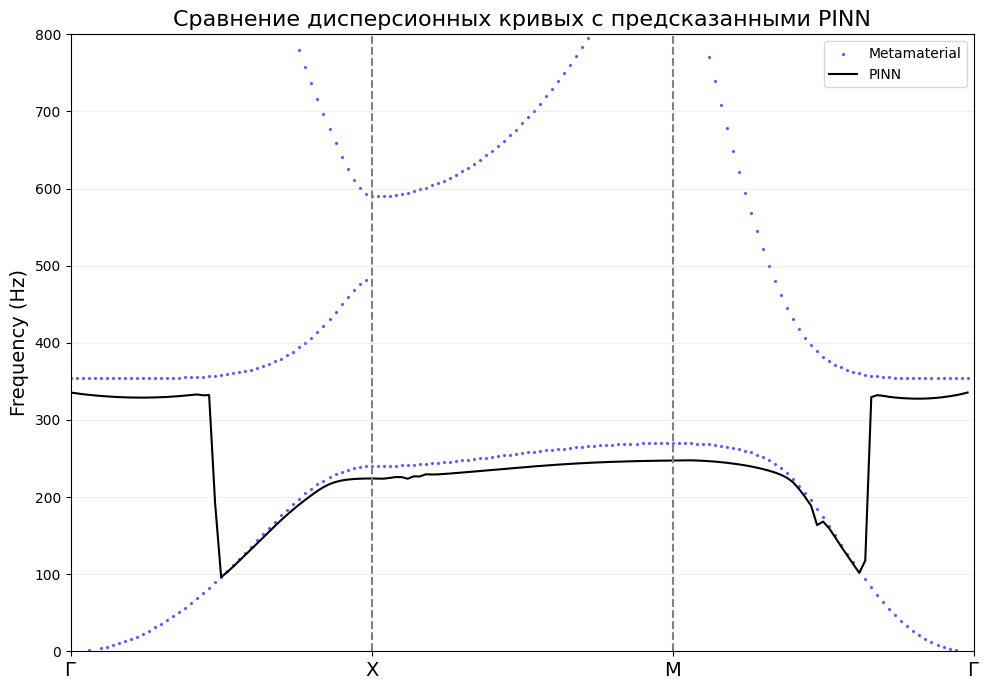

In [55]:
base_params = {
    "a": 0.1,
    "b": 0.1,
    "theta": np.pi / 2.0,
    "D": 51.28,
    "rho":  2700,
    "h": 0.002,
    "m_u": 0.027,
    "ks": 9.593 * 10**4
}

base_meta = MetaMaterial(**base_params)
base_w_search = np.linspace(0.005, 800 * 2 * np.pi, 500)
base_bz = BrilloinZone(base_params["a"], base_params["b"], N_seg=50)
base_KX, base_KY, base_x_path = base_bz.get_path()
base_meta_x, base_meta_y = base_meta.calculate_bands(base_KX, base_KY, base_w_search)

base_pinn_y = []
for kx, ky in zip(base_KX, base_KY):
    pinn_params = {**base_params, "kx": kx, "ky": ky}
    base_pinn_y.append(predict_omega(pinn_params))

plot_dispersion(
    base_meta_x,
    base_meta_y,
    base_meta,
    base_bz,
    pinn_x=base_x_path,
    pinn_y=np.array(base_pinn_y),
    title="Сравнение дисперсионных кривых с предсказанными PINN",
)